### Setting up the Environment and Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
import os

warnings.filterwarnings('ignore')


pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.float_format', '{:.2f}'.format)


plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')


RAW_PATH      = '../data/weekly_base_bundles_info_202501_202510.csv'
INTERIM_PATH  = '../data/interim/telecom_bundles_cleaned.csv'
PROCESSED_PATH= '../data/processed/telecom_bundles_final.csv'

print("The environment is ready.")

The environment is ready.


###  Phase 1 – Data Loading and Initial Inspection

In [ ]:

df = pd.read_csv(RAW_PATH)
df_backup = df.copy()  # Backup copy in memory

print(f" Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

df = df.drop('total_duration', axis=1)

print("\n--- First 5 rows ---")
display(df.head())

print("\n--- Last 5 rows ---")
display(df.tail())


print("\n--- Data types and non-null values ---")
df.info()


print("\n--- Numerical columns statistics ---")
display(df.describe())

print("\n--- Categorical columns statistics ---")
display(df.describe(include='object'))

 Loaded: 42,377 rows × 15 columns

--- First 5 rows ---


,week_number,year_number,bundle_id,bundle_name,bundle_type,validity,price,usage_type,configured_volume,service_class_category,total_rev,total_subscriptions,total_sessions,unique_users
0,1,2025,37076,Forfait 1.6Go 30 jours@4000F,BUNDLE_DATA,30 Day(s),4000,CHARGED,1.61,PREPAID,36000.00,9,10,9
1,1,2025,50134,Forfait appels RCA 2 mins 30 jours@690F,INT_BUNDLE_VOICE,30 Day(s),690,CHARGED,2MIN,PREPAID,3450.00,5,5,5
2,1,2025,50129,Forfait appels Nigeria 2 mins 30 jours@200F,INT_BUNDLE_VOICE,30 Day(s),200,CHARGED,2MIN,PREPAID,400.00,2,2,1
3,1,2025,35070,Forfait 1 jour 170MB@215F,BUNDLE_DATA,1 Day(s),215,CHARGED,170,PREPAID,124060.00,577,584,340
4,1,2025,36667,NDAKO BOX ILLIMITE@50050F,BUNDLE_DATA,30 Day(s),50050,CHARGED,Unlimited,PREPAID,200200.00,4,4,4



--- Last 5 rows ---


,week_number,year_number,bundle_id,bundle_name,bundle_type,validity,price,usage_type,configured_volume,service_class_category,total_rev,total_subscriptions,total_sessions,unique_users
42372,44,2025,9032,300 SMS vers MTN ou 83 vers autre 5 jours@335F,BUNDLE_SMS,5 Day(s),335,CHARGED,300sms,PREPAID,253295.86,772,783,718
42373,44,2025,FVX7D525FV4,MaGicvoice 40+3Mins 7 jours@525F,BUNDLE_VOICE,7 Day(s),525,CHARGED,40 + 3Mins,NaN,525.00,1,1,1
42374,44,2025,50155,Forfait appels Cote d Ivoire 15 mins 30 jours@2999,INT_BUNDLE_VOICE,30 Day(s),2999,CHARGED,15MIN,PREPAID,2999.00,1,1,1
42375,44,2025,36203,Maxinet Debutant 500MB 7 jours@550F,BUNDLE_DATA,7 Day(s),550,CHARGED,500MB,HYBRID,1650.00,3,3,1
42376,44,2025,36848,Zone A and B NDAKO 550GB 30 Jours@26500F,BUNDLE_DATA,30 Day(s),26500,CHARGED,550GB,HYBRID,53000.00,2,2,2



--- Data types and non-null values ---
<class 'pandas.DataFrame'>
RangeIndex: 42377 entries, 0 to 42376
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   week_number             42377 non-null  int64  
 1   year_number             42377 non-null  int64  
 2   bundle_id               42276 non-null  str    
 3   bundle_name             42251 non-null  str    
 4   bundle_type             42251 non-null  str    
 5   validity                40917 non-null  str    
 6   price                   40936 non-null  str    
 7   usage_type              42251 non-null  str    
 8   configured_volume       37270 non-null  str    
 9   service_class_category  41850 non-null  str    
 10  total_rev               42377 non-null  float64
 11  total_subscriptions     42377 non-null  int64  
 12  total_sessions          42377 non-null  int64  
 13  unique_users            42377 non-null  int64  
dtypes: float6

,week_number,year_number,total_rev,total_subscriptions,total_sessions,unique_users
count,42377.00,42377.00,42377.00,42377.00,42377.00,42377.00
mean,22.90,2025.00,2462037.79,11378.58,11384.02,5745.38
std,12.57,0.00,16870336.37,93860.51,93880.48,40397.64
min,1.00,2025.00,-7654947.00,1.00,0.00,1.00
25%,12.00,2025.00,3400.00,3.00,3.00,2.00
50%,23.00,2025.00,28710.00,18.00,18.00,13.00
75%,34.00,2025.00,280500.00,288.00,289.00,188.00
max,44.00,2025.00,535384882.76,2990502.00,2990502.00,1135805.00



--- Categorical (Object) columns statistics ---


,bundle_id,bundle_name,bundle_type,validity,price,usage_type,configured_volume,service_class_category
count,42276,42251,42251,40917,40936,42251,37270,41850
unique,1101,1052,7,27,361,2,488,4
top,1637,SMS Bundle 3 Days@122F,BUNDLE_DATA,1 Day(s),450,CHARGED,15MIN,PREPAID
freq,190,209,21185,11650,1130,42239,1889,28713


### Phase 2 – EDA (Exploration and Analysis)

##### 2.1 Missing Value Analysis

                Column  Missing Count  Percentage %
     configured_volume           5107         12.05
              validity           1460          3.45
                 price           1441          3.40
service_class_category            527          1.24
           bundle_type            126          0.30
           bundle_name            126          0.30
            usage_type            126          0.30
             bundle_id            101          0.24


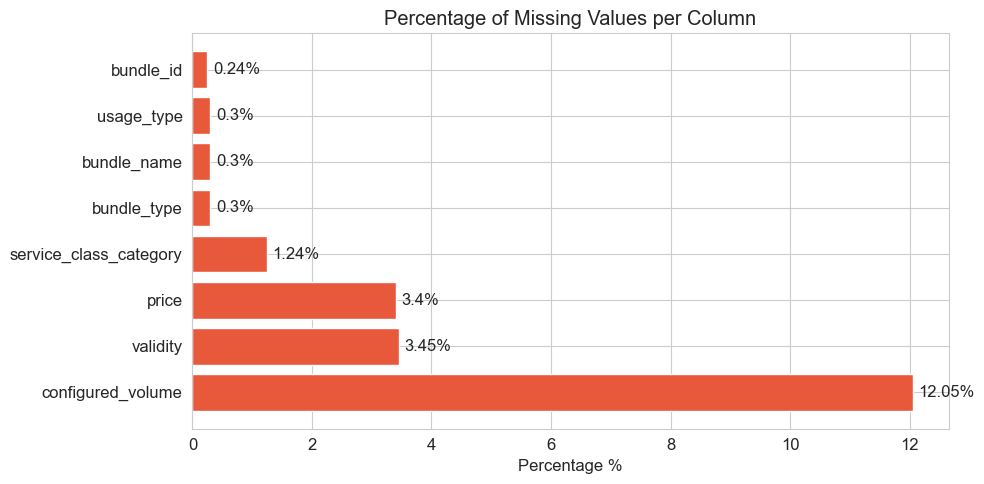


Distribution of missing columns count per row:
0    36840
1     4010
2      111
3     1361
4       55
Name: count, dtype: int64


In [9]:

missing = pd.DataFrame({
    'Column': df.columns,
    'Missing Count': df.isnull().sum().values,
    'Percentage %': (df.isnull().sum() / len(df) * 100).round(2).values
}).sort_values('Percentage %', ascending=False)


missing = missing[missing['Missing Count'] > 0]
print(missing.to_string(index=False))


output_dir = 'reports/figures'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)


fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(missing['Column'], missing['Percentage %'], color='#E8593C')
ax.set_xlabel('Percentage %')
ax.set_title('Percentage of Missing Values per Column')


for i, v in enumerate(missing['Percentage %']):
    ax.text(v + 0.1, i, f'{v}%', va='center')

plt.tight_layout()
plt.savefig(f'{output_dir}/missing_values.png', dpi=150)
plt.show()

# --- Check Co-occurrence: Are values missing in the same rows? ---
critical_cols = ['validity', 'price', 'configured_volume', 'service_class_category']
missing_combo = df[critical_cols].isnull().sum(axis=1).value_counts().sort_index()

print("\nDistribution of missing columns count per row:")
print(missing_combo)

In [ ]:

check_rows = df[df[critical_cols].isnull().sum(axis=1) == 3]
print(check_rows[critical_cols + ['bundle_name']].head(10))

    validity price configured_volume service_class_category  \
10       NaN   NaN               NaN                  STAFF   
46       NaN   NaN               NaN                PREPAID   
60       NaN   NaN               NaN                  STAFF   
63       NaN   NaN               NaN                 HYBRID   
103      NaN   NaN               NaN                PREPAID   
163      NaN   NaN               NaN                  STAFF   
179      NaN   NaN               NaN                PREPAID   
201      NaN   NaN               NaN                PREPAID   
213      NaN   NaN               NaN                PREPAID   
225      NaN   NaN               NaN                PREPAID   

                        bundle_name  
10                         MTN ME2U  
46       Forfait DIY COMBO DATA LOW  
60          Forfait DIY VOICE ONNET  
63                 MTN Call Me Back  
103  FORFAIT PRO STAFF CHANGE OFFER  
163         Forfait DIY DATA MEDIUM  
179                        MTN ME2U  
20

In [ ]:

staff_vs_others = df.groupby(df['bundle_name'].str.contains('STAFF', na=False))['total_rev'].mean()
print("Average Revenue: Staff (True) vs Customers (False)")
print(staff_vs_others)


diy_missing = df[df['bundle_name'].str.contains('DIY', na=False)]['configured_volume'].isnull().sum()
print(f"\nMissing volumes in DIY bundles: {diy_missing}")

Average Revenue: Staff (True) vs Customers (False)
bundle_name
False   2462792.90
True       1313.85
Name: total_rev, dtype: float64

Missing volumes in DIY bundles: 762


##### 2.2 Distribution Analysis

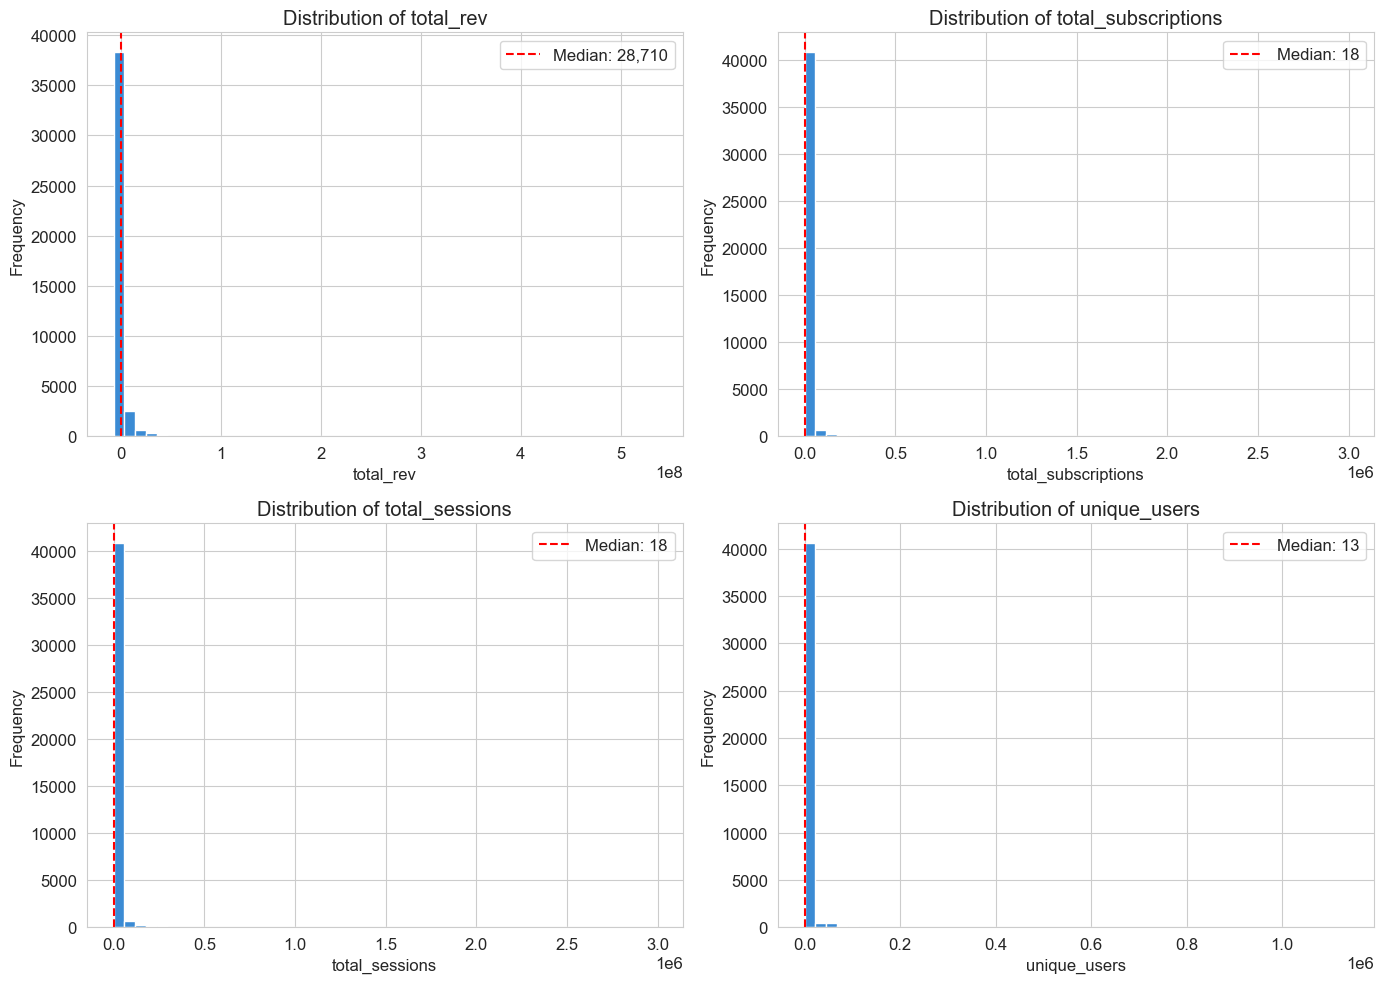

Skewness for numerical columns:
  total_rev: 19.40  High Skewness
  total_subscriptions: 19.76  High Skewness
  total_sessions: 19.74  High Skewness
  unique_users: 16.55  High Skewness


In [ ]:

numerical_cols = ['total_rev', 'total_subscriptions', 'total_sessions', 'unique_users']


fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    
    axes[i].hist(df[col], bins=50, color='#3B8BD4', edgecolor='white')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    
    
    median_val = df[col].median()
    axes[i].axvline(median_val, color='red', linestyle='--',
                    label=f'Median: {median_val:,.0f}')
    axes[i].legend()

plt.tight_layout()
plt.savefig('reports/figures/distributions_numerical.png', dpi=150)
plt.show()


print("Skewness for numerical columns:")
for col in numerical_cols:
    skew = df[col].skew()
    
    flag = " High Skewness" if abs(skew) > 1 else "  Moderate/Normal"
    print(f"  {col}: {skew:.2f} {flag}")

##### 2.3 Analysis of Categorical Columns


Column: bundle_type
Number of unique categories: 7
bundle_type
BUNDLE_DATA           50.14
BUNDLE_VOICE          30.77
INT_BUNDLE_VOICE      11.99
BUNDLE_SMS             4.75
VAS                    1.22
FLEXI_BUNDLE           1.01
OFFNET_BUNDLE_VOICE    0.11

Column: usage_type
Number of unique categories: 2
usage_type
CHARGED   99.97
FREE       0.03

Column: service_class_category
Number of unique categories: 4
service_class_category
PREPAID    68.61
HYBRID     23.60
STAFF       7.50
POSTPAID    0.29


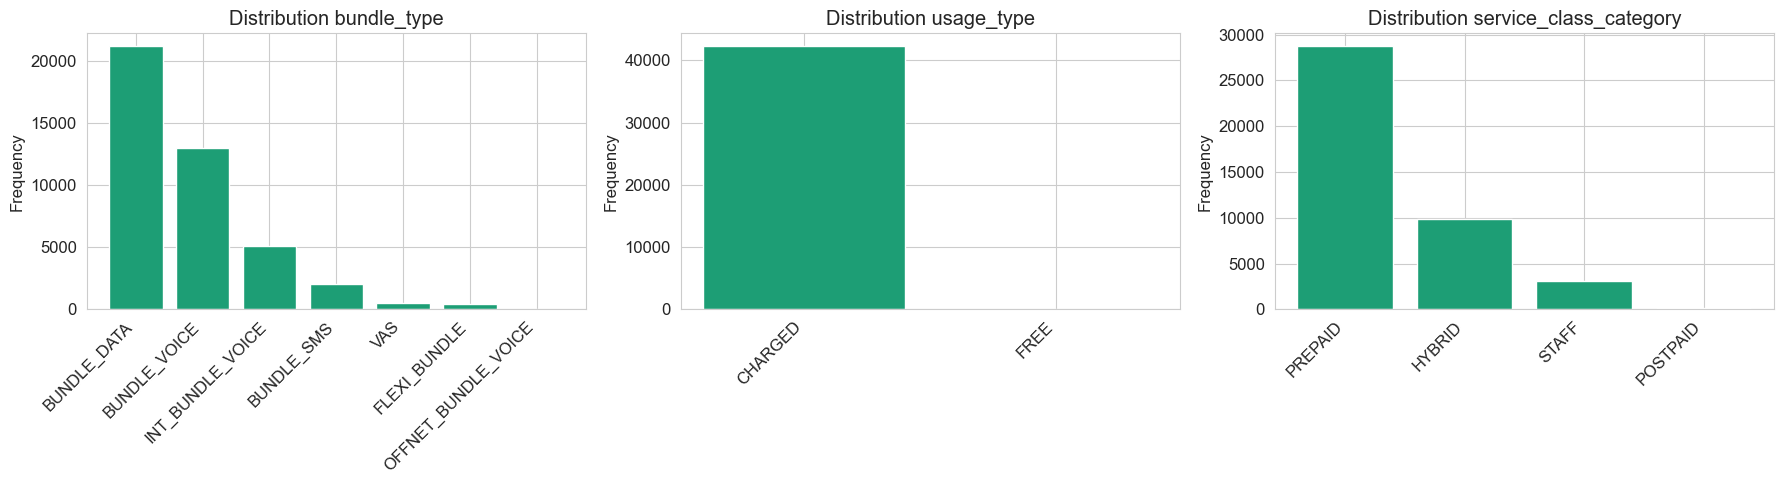

In [ ]:

categorical_cols = ['bundle_type', 'usage_type', 'service_class_category']

for col in categorical_cols:
    print(f"\n{'='*50}")
    print(f"Column: {col}")
    print(f"Number of unique categories: {df[col].nunique()}")
    print(df[col].value_counts(normalize=True).mul(100).round(2).to_string())


fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(categorical_cols):
    counts = df[col].value_counts().head(10)
    axes[i].bar(range(len(counts)), counts.values, color='#1D9E75')
    axes[i].set_xticks(range(len(counts)))
    axes[i].set_xticklabels(counts.index, rotation=45, ha='right')
    axes[i].set_title(f'Distribution {col}')
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('reports/figures/distributions_categorical.png', dpi=150)
plt.show()

##### 2.4 Outlier Analysis

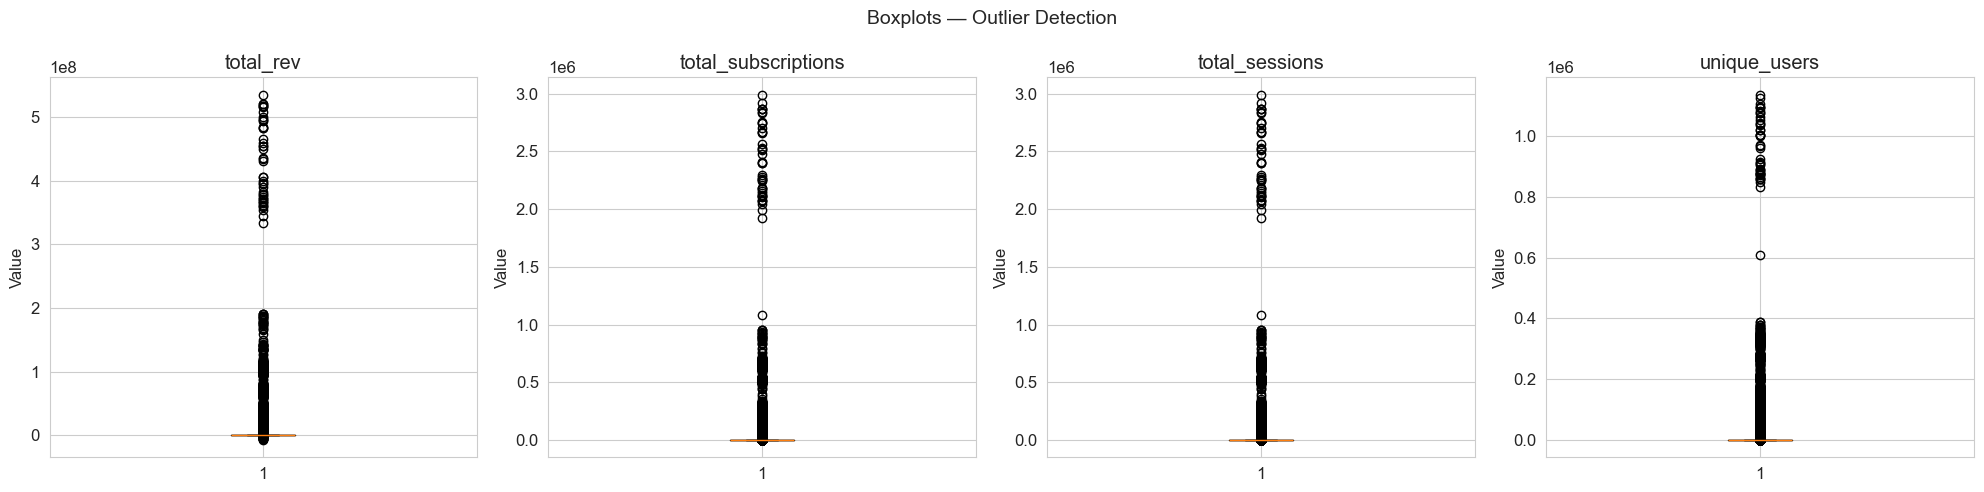


Outlier percentage per column (IQR Method):
  total_rev: 7,572 outliers (17.9%)
  total_subscriptions: 8,455 outliers (20.0%)
  total_sessions: 8,459 outliers (20.0%)
  unique_users: 8,424 outliers (19.9%)


In [ ]:

fig, axes = plt.subplots(1, len(numerical_cols), figsize=(20, 5))

for i, col in enumerate(numerical_cols):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col)
    axes[i].set_ylabel('Value')

plt.suptitle('Boxplots — Outlier Detection', fontsize=14)
plt.tight_layout()
plt.savefig('reports/figures/outliers_boxplot.png', dpi=150)
plt.show()

# --- Calculate Outlier Percentage using the IQR Method ---
print("\nOutlier percentage per column (IQR Method):")
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # Define boundaries
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Filter outliers
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    n_outliers = outliers.shape[0]
    percentage = (n_outliers / len(df)) * 100
    
    print(f"  {col}: {n_outliers:,} outliers ({percentage:.1f}%)")

##### 2.5 Analysis of Relationships Between Columns

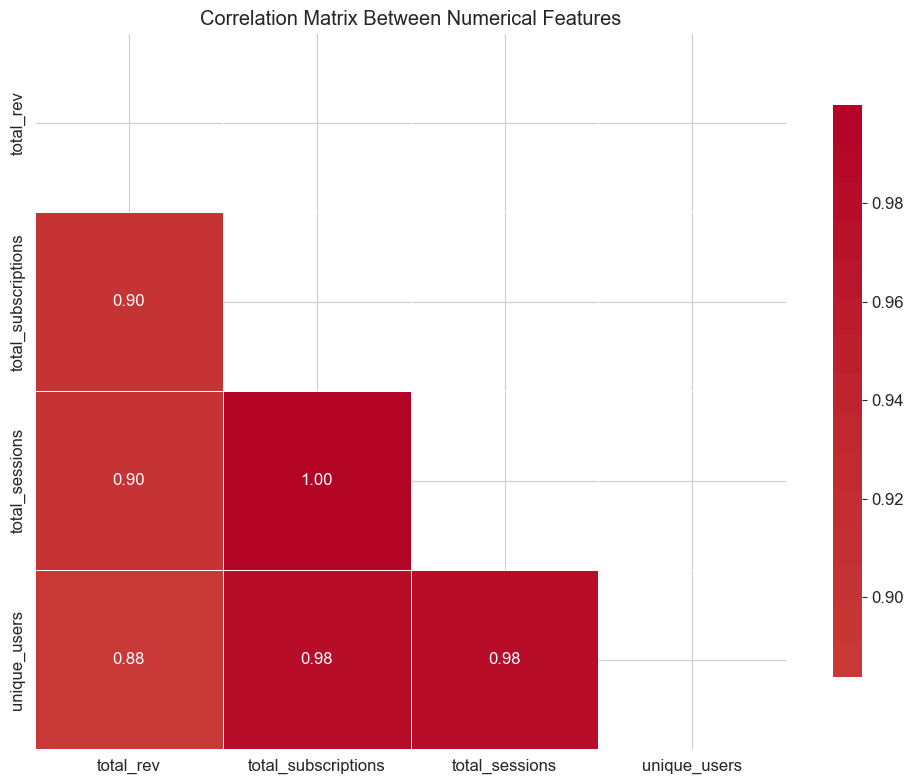

 Highly correlated columns (>0.9):
  total_rev ↔ total_subscriptions: 0.90
  total_rev ↔ total_sessions: 0.90
  total_subscriptions ↔ total_sessions: 1.00
  total_subscriptions ↔ unique_users: 0.98
  total_sessions ↔ unique_users: 0.98


In [ ]:


corr_matrix = df[numerical_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=ax,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix Between Numerical Features')
plt.tight_layout()
plt.savefig('reports/figures/correlation_heatmap.png', dpi=150)
plt.show()


high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.9:
            high_corr.append((corr_matrix.columns[i],
                               corr_matrix.columns[j],
                               corr_matrix.iloc[i, j]))

if high_corr:
    print(" Highly correlated columns (>0.9):")
    for a, b, v in high_corr:
        print(f"  {a} ↔ {b}: {v:.2f}")
else:
    print("No high correlations requiring removal")

# # --- Save EDA summary ---
# eda_summary = {
#     'total_rows': len(df),
#     'total_cols': len(df.columns),
#     'missing_cols': missing['Column'].tolist(),
#     'high_skew_cols': [col for col in numerical_cols if abs(df[col].skew()) > 1],
#     'high_corr_pairs': high_corr
# }

# print("\n EDA Summary:")
# for k, v in eda_summary.items():
#     print(f"  {k}: {v}")